In [70]:
import numpy as np
import pandas as pd

In [71]:
import matplotlib.pyplot as plt

In [72]:
df = pd.read_csv('placement-2.csv')

In [73]:
df.shape

(200, 2)

In [74]:
df.head()


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [75]:
x = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [76]:
type(x)

pandas.core.frame.DataFrame

Text(0, 0.5, 'package')

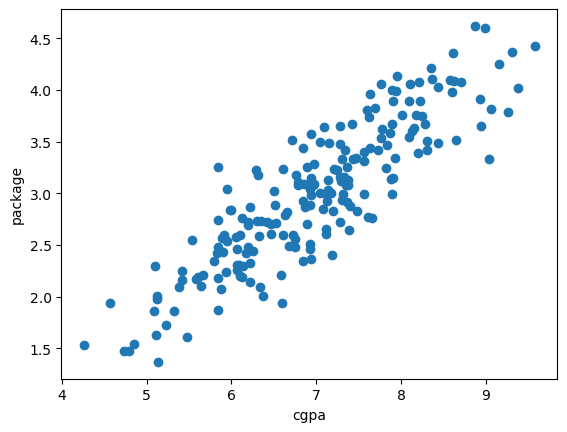

In [77]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')

In [78]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
lr = LinearRegression()

In [81]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'package')

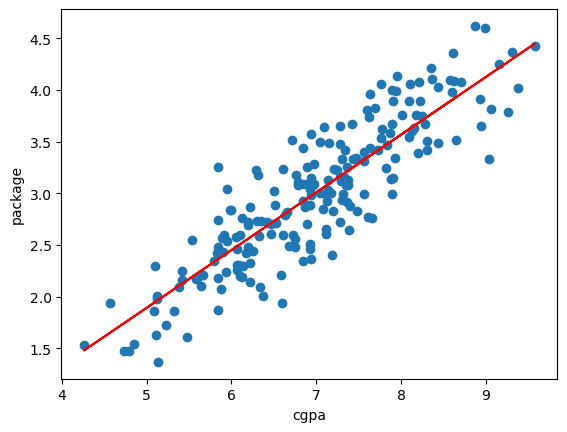

In [82]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(x_train, lr.predict(x_train), color = 'red')
plt.xlabel('cgpa')
plt.ylabel('package')

In [83]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [84]:
y_pred = lr.predict(x_test)

In [85]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [86]:
print('MAE:', mean_absolute_error(y_test, y_pred))

MAE: 0.2884710931878175


In [87]:
print('MSE:', mean_squared_error(y_test, y_pred))

MSE: 0.12129235313495527


In [90]:
print('RMSE:', np.sqrt(mean_absolute_error(y_test, y_pred)))

RMSE: 0.5370950504220063


In [91]:
print('R2 Sore:', r2_score(y_test, y_pred))

R2 Sore: 0.780730147510384


In [92]:
r2 = r2_score(y_test, y_pred)

In [93]:
x_test.shape

(40, 1)

In [94]:
1 - ( ((1 - r2)* (40 -1)) / (40-1-1) ) #adjusted r2

0.7749598882343415

In [95]:
#adding random column to compare r2 and adjusted r2

In [96]:
new_df= df.copy()
new_df['random_col'] = np.random.random(200)

new_df = new_df[['cgpa', 'random_col', 'package']]
new_df.head()

,cgpa,random_col,package
0,6.89,0.261426,3.26
1,5.12,0.928405,1.98
2,7.82,0.910600,3.25
3,7.42,0.550819,3.67
4,6.94,0.008770,3.57


Text(0, 0.5, 'random column')

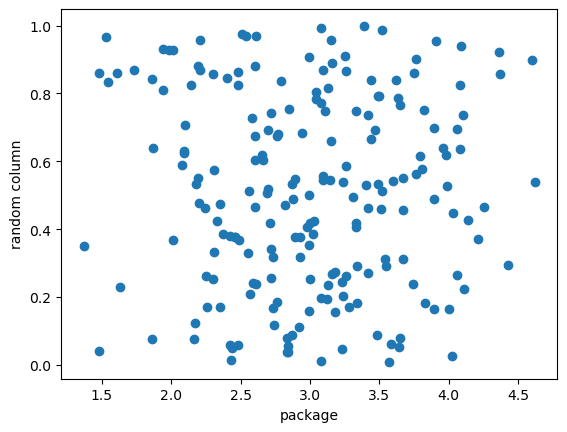

In [97]:
plt.scatter(new_df['package'], new_df['random_col'])
plt.xlabel('package')
plt.ylabel('random column')

In [98]:
x2 = new_df.iloc[:, 0:2]
y2 = new_df.iloc[:, -1]

In [99]:
lr2 = LinearRegression()

In [100]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size = 0.2, random_state = 2)

In [101]:
lr2.fit(x_train2, y_train2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
y_pred2 = lr2.predict(x_test2)

In [103]:
y_test2.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [110]:
print('r2 Score: ', r2_score(y_test2, y_pred2)) ##very slightly increased r2

r2 Score:  0.7860375225121778


In [111]:
r22 = r2_score(y_test2, y_pred2)

In [112]:
1 - ( ((1 - r22)* (40 -1)) / (40-1-2) ) #very slightly decreased adjusted r2

0.7744719831885118